<a href="https://colab.research.google.com/github/sri4022220/ML-on-Big-Data_Assignment/blob/main/Week_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
spark = SparkSession.builder \
.appName("Perceptron_Email_Classification") \
.getOrCreate()

In [3]:
df = spark.read.csv("/content/emails.csv", header=True,inferSchema=True)
df.show(5)

+---------+---+---+---+---+---+---+---+---+---+---+---+---+----+-----+---+---+----+----+----+----+----+---+---+---+---+---+---+---+---+----+---+---+---+---+----+---+-----+---+------+---+---+---+---+----+---+---+---+---+---+----+----+---+---------+---+---+---+---+---+-----+------+---+---+---+---+---+---+-----+-----+-----+---+----+-------+---+-----+---+---+-----+---+----+---+------+--------+---+-----------+----+-------+---+----+---+---+----+----+----+---+------+----+--------+-----+-----+----+------+------+-----+-----+---+------+---+---------+---+-----+-------+---+---+---+-----+----+----+-----+----+----+----+------+-----+----+----+---+----+---+---------+---+----------+----+----+----+----+--------+----+-----+---+------+---+---+-----+----+---+------+-----+-------+----+----+----+----------+------+---+-----+------+----+---+---+-----+------+--------+----+---+-------+----+-------+----+----+-----+---+-----+-----+---+---+---+---+-----+----------+---+----+---+----+-----+---+---------+----+-------+

In [4]:
df.groupBy("Prediction").count().show()

+----------+-----+
|Prediction|count|
+----------+-----+
|         1| 1500|
|         0| 3672|
+----------+-----+



In [5]:
from pyspark.sql.functions import col,isnan, when, count
df.select([count(when(col(f"`{c}`").isNull(), col(f"`{c}`"))).alias(c) for c in df.columns]
).show()

+---------+---+---+---+---+---+---+---+---+---+---+---+---+----+-----+---+---+----+----+----+----+----+---+---+---+---+---+---+---+---+----+---+---+---+---+----+---+-----+---+------+---+---+---+---+----+---+---+---+---+---+----+----+---+---------+---+---+---+---+---+-----+------+---+---+---+---+---+---+-----+-----+-----+---+----+-------+---+-----+---+---+-----+---+----+---+------+--------+---+-----------+----+-------+---+----+---+---+----+----+----+---+------+----+--------+-----+-----+----+------+------+-----+-----+---+------+---+---------+---+-----+-------+---+---+---+-----+----+----+-----+----+----+----+------+-----+----+----+---+----+---+---------+---+----------+----+----+----+----+--------+----+-----+---+------+---+---+-----+----+---+------+-----+-------+----+----+----+----------+------+---+-----+------+----+---+---+-----+------+--------+----+---+-------+----+-------+----+----+-----+---+-----+-----+---+---+---+---+-----+----------+---+----+---+----+-----+---+---------+----+-------+

In [7]:
df = df.withColumnRenamed("Email No.", "Email_No")

feature_columns = [col for col in df.columns if col != 'Email_No' and col != 'Prediction']
if 'features' in df.columns:
    df = df.drop('features')

feature_columns = [col for col in df.columns if col != 'Email_No' and col != 'Prediction']
print("DataFrame Schema before VectorAssembler:")
df.printSchema()

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)
assembled = assembler.transform(df)

DataFrame Schema before VectorAssembler:
root
 |-- Email_No: string (nullable = true)
 |-- the: integer (nullable = true)
 |-- to: integer (nullable = true)
 |-- ect: integer (nullable = true)
 |-- and: integer (nullable = true)
 |-- for: integer (nullable = true)
 |-- of: integer (nullable = true)
 |-- a: integer (nullable = true)
 |-- you: integer (nullable = true)
 |-- hou: integer (nullable = true)
 |-- in: integer (nullable = true)
 |-- on: integer (nullable = true)
 |-- is: integer (nullable = true)
 |-- this: integer (nullable = true)
 |-- enron: integer (nullable = true)
 |-- i: integer (nullable = true)
 |-- be: integer (nullable = true)
 |-- that: integer (nullable = true)
 |-- will: integer (nullable = true)
 |-- have: integer (nullable = true)
 |-- with: integer (nullable = true)
 |-- your: integer (nullable = true)
 |-- at: integer (nullable = true)
 |-- we: integer (nullable = true)
 |-- s: integer (nullable = true)
 |-- are: integer (nullable = true)
 |-- it: integer (nu

In [8]:
scaler = StandardScaler(
inputCol="features",outputCol="scaledFeatures",

withMean=True,withStd=True)
scalerModel = scaler.fit(assembled)
scaledData = scalerModel.transform(assembled)

In [9]:
trainData, testData = scaledData.randomSplit([0.8,0.2],seed=123)

In [10]:
train = trainData.select("scaledFeatures","Prediction").collect()
test = testData.select("scaledFeatures","Prediction").collect()
X_train = np.array([r.scaledFeatures.toArray() for r in train])
y_train = np.array([r.Prediction for r in train])
X_test = np.array([r.scaledFeatures.toArray() for r in test])
y_test = np.array([r.Prediction for r in test])

In [12]:
class Perceptron:
    def __init__(self, lr=0.01, epochs=20):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        self.loss = []
        y = np.where(y == 0, -1, 1)
        for epoch in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                prediction = np.dot(xi, self.weights) + self.bias
                pred = 1 if prediction >= 0 else -1
                update = self.lr * (target - pred)
                self.weights += update * xi
                self.bias += update
                if update != 0:
                    errors += 1
            self.loss.append(errors)

    def predict(self, X):
        prediction = np.dot(X, self.weights) + self.bias
        return np.where(prediction >= 0, 1, 0)

In [13]:
model = Perceptron(lr=0.01,epochs=30)
model.fit(X_train,y_train)

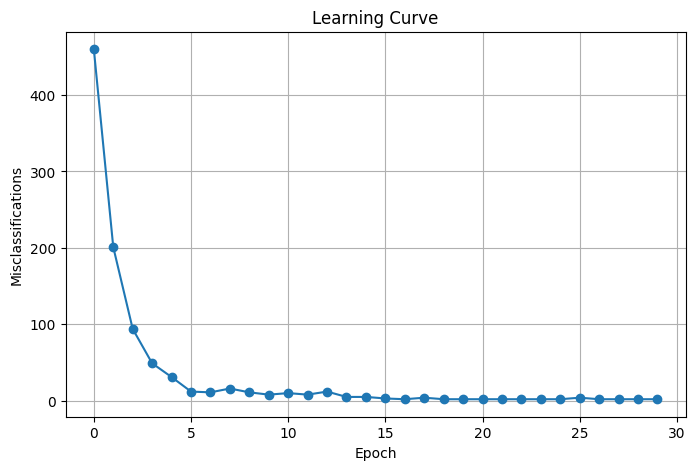

In [14]:
plt.figure(figsize=(8,5))
plt.plot(model.loss,marker='o')
plt.xlabel("Epoch")
plt.ylabel("Misclassifications")
plt.title("Learning Curve")
plt.grid(True)
plt.show()

In [15]:
y_pred = model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy :",accuracy)

Accuracy : 0.9555765595463138


In [17]:
precision = precision_score(y_test,y_pred)
print("Precision :",precision)

Precision : 0.906158357771261


In [18]:
recall = recall_score(y_test,y_pred)
print("Recall :",recall)

Recall : 0.9537037037037037


In [19]:
f1 = f1_score(y_test,y_pred)
print("F1 Score :",f1)

F1 Score : 0.9293233082706767


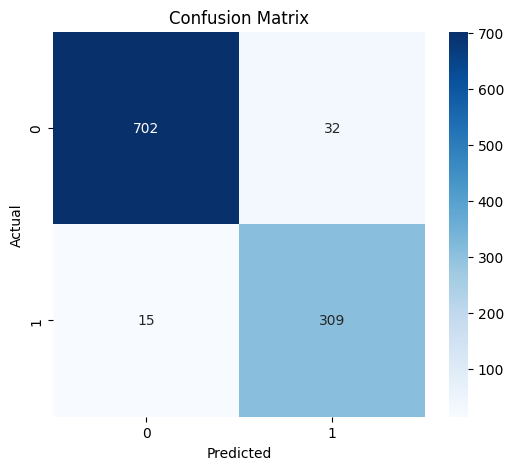

In [20]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

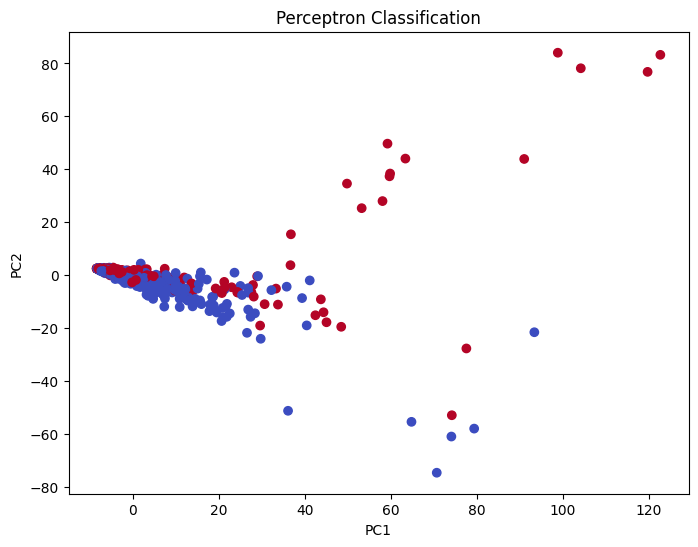

In [21]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_test)
plt.figure(figsize=(8,6))
plt.scatter(
X_vis[:,0],
X_vis[:,1],
c=y_pred,
cmap="coolwarm"
)
plt.title("Perceptron Classification")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()